In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P8 - Wrong unit of analysis

## 1. What goes wrong
Users are randomised but sessions are analysed as if they were independent. Sessions from the same user are correlated, so the standard error is too small and false positives rise.

## 2. Simulate

In [2]:
from abtest.pitfalls import unit_of_analysis
ua = unit_of_analysis.unit_of_analysis_fpr(n_sims=500)
ua.round(3)

,user_sd,naive_session_level_fpr,delta_method_fpr
0,0.0,0.060,0.060
1,0.5,0.054,0.042
2,1.0,0.096,0.038
3,1.5,0.160,0.048
4,2.0,0.250,0.056


## 3. Quantify the damage

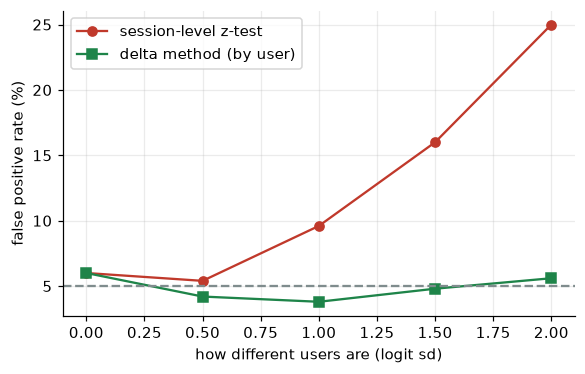

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(ua.user_sd, ua.naive_session_level_fpr * 100, 'o-', color=BAD, label='session-level z-test'); ax.plot(ua.user_sd, ua.delta_method_fpr * 100, 's-', color=GOOD, label='delta method (by user)'); ax.axhline(5, color=NEUTRAL, ls='--'); ax.legend(); ax.set(xlabel='how different users are (logit sd)', ylabel='false positive rate (%)'); plt.show()

## 4. Detect

Ask what the randomisation unit is and whether the denominator of the metric is that unit. Ratio metrics (CTR, AOV) are the usual trap.

## 5. Fix

Analyse at the randomisation unit. For ratio metrics use the **delta method** (or a bootstrap resampling users).

## 6. Verify the fix

In [4]:
print(ua[['user_sd', 'naive_session_level_fpr', 'delta_method_fpr']].round(3).to_string(index=False))

 user_sd  naive_session_level_fpr  delta_method_fpr
     0.0                    0.060             0.060
     0.5                    0.054             0.042
     1.0                    0.096             0.038
     1.5                    0.160             0.048
     2.0                    0.250             0.056


## So what
The more users differ from each other, the worse the session-level test gets, reaching several times the nominal rate. The delta method stays near 5%.